### Overview
In this notebook, we evaluate traditional, widely used machine learning paradigms for supervised learning on tabular data. 
Before exploring complex deep learning architectures, it is essential to establish strong, interpretable baselines. 

We will systematically evaluate each model across two distinct domains simultaneously:
* **Standard Tabular Data:** A classic dataset containing a mix of informative and noise features, typical of finance or standard clinical records.
* **Biological Data ($P \gg N$):** A high-dimensional oncology dataset characterized by having significantly more features (genes) than samples (patients). This domain is highly susceptible to the "Curse of Dimensionality" and extreme overfitting.

**Terminology:**
* **$N$ (Number of Samples):** The number of data points in the dataset. 
* **$P$ (Number of Features):** The number of dimensions for each sample. In our datasets, while some dimensions contain the true informative signal, there are also additional nuisance dimensions (noise). These nuisance dimensions are irrelevant to the underlying structure of the data and serve to challenge the feature selection and classification algorithms.

### Data Generation: Standard vs. High-Dimensional Domains

We begin by importing the necessary libraries and generating our two synthetic tabular datasets. We fix the random seed to ensure reproducibility.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# 1. Standard Tabular Data (N=1000, P=20)
X_std, y_std = make_classification(n_samples=1000, n_features=20, n_informative=5, random_state=42)
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y_std,test_size=0.3, random_state=42 )

# 2. High-Dimensional Biological Data (N=500, P=2000)
X_bio, y_bio = make_classification(n_samples=500, n_features=2000,n_informative=10, random_state=42)
X_train_bio, X_test_bio, y_train_bio, y_test_bio = train_test_split(X_bio, y_bio,test_size=0.3,random_state=42 )

print(f"Standard Data - Train: {X_train_std.shape}, Test: {X_test_std.shape}")
print(f"Biological Data - Train: {X_train_bio.shape}, Test: {X_test_bio.shape}")


Standard Data - Train: (700, 20), Test: (300, 20)
Biological Data - Train: (350, 2000), Test: (150, 2000)


### Linear Baselines: Standard Logistic Regression vs. LASSO

We begin with linear models. Standard Logistic Regression provides a highly interpretable baseline, but it lacks built-in feature selection. To counter this, we introduce **LASSO (L1 Regularization)**, which forces the weights of irrelevant features to exactly zero.

**The Importance of Feature Scaling:**
Algorithms that apply a penalty to feature weights (like LASSO) are highly sensitive to the scale of the data. If one feature ranges from 0-1 and another from 0-1000, the regularization will unfairly penalize the larger feature. Therefore, we must apply `StandardScaler` to normalize our data ($mean=0$, $variance=1$) before training linear models.

In [2]:
# Initialize Scalers
scaler_std = StandardScaler()
scaler_bio = StandardScaler()

# Scale Standard Data
X_train_std_scaled = scaler_std.fit_transform(X_train_std)
X_test_std_scaled = scaler_std.transform(X_test_std)

# Scale Biological Data
X_train_bio_scaled = scaler_bio.fit_transform(X_train_bio)
X_test_bio_scaled = scaler_bio.transform(X_test_bio)

# Define evaluation function
def train_and_eval(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    return accuracy_score(y_te, model.predict(X_te))

# Initialize Models
lr = LogisticRegression(penalty=None, max_iter=500)
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=500, random_state=42)

print("--- Standard Data (P=20) ---")
lr_std_acc = train_and_eval(lr, X_train_std_scaled, y_train_std, X_test_std_scaled, y_test_std)
lasso_std_acc = train_and_eval(lasso, X_train_std_scaled, y_train_std, X_test_std_scaled, y_test_std)
print(f"Standard LR Accuracy: {lr_std_acc:.3f}")
print(f"LASSO (L1) Accuracy:  {lasso_std_acc:.3f}")

print("\n--- Biological Data (P=2000) ---")
lr_bio_acc = train_and_eval(lr, X_train_bio_scaled, y_train_bio, X_test_bio_scaled, y_test_bio)
lasso_bio_acc = train_and_eval(lasso, X_train_bio_scaled, y_train_bio, X_test_bio_scaled, y_test_bio)
print(f"Standard LR Accuracy: {lr_bio_acc:.3f}")
print(f"LASSO (L1) Accuracy:  {lasso_bio_acc:.3f}")

# Calculate retained features for LASSO on biological data
lasso.fit(X_train_bio_scaled, y_train_bio)
retained_bio = np.sum(lasso.coef_ != 0)
print(f"\n* Note: On the biological data, LASSO retained only {retained_bio} out of 2000 features.")

# For the standard data (needed for the final plot)
lasso.fit(X_train_std_scaled, y_train_std)
retained_std = np.sum(lasso.coef_ != 0)

--- Standard Data (P=20) ---
Standard LR Accuracy: 0.807
LASSO (L1) Accuracy:  0.807

--- Biological Data (P=2000) ---
Standard LR Accuracy: 0.567
LASSO (L1) Accuracy:  0.807

* Note: On the biological data, LASSO retained only 97 out of 2000 features.


### Gradient Boosted Decision Trees (XGBoost)

XGBoost represents the state-of-the-art for traditional tabular data. It handles non-linearities and unnormalized data natively. 

However, tree-based models can struggle when the signal-to-noise ratio is extremely low (as seen in our biological dataset with 1,990 noise features). Let's evaluate its robustness across both domains.

In [3]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=45)

print("--- XGBoost Performance ---")
xgb_std_acc = train_and_eval(xgb_model, X_train_std, y_train_std, X_test_std, y_test_std)
xgb_bio_acc = train_and_eval(xgb_model, X_train_bio, y_train_bio, X_test_bio, y_test_bio)

print(f"Accuracy on Standard Data: {xgb_std_acc:.3f}")
print(f"Accuracy on Biological Data: {xgb_bio_acc:.3f}")

--- XGBoost Performance ---
Accuracy on Standard Data: 0.947
Accuracy on Biological Data: 0.787


### Systematic Comparison

Visualizing the raw accuracy side-by-side reveals the fundamental behavior of tabular machine learning across domains:

* **The Standard Domain:** XGBoost demonstrates its dominance, efficiently capturing the underlying patterns to achieve near-perfect accuracy.
* **The High-Dimensional Domain:** Extreme dimensionality and proper data scaling expose the vulnerability of standard linear models (collapsing to near-random performance). Even XGBoost struggles with the overwhelming noise. Here, the LASSO penalty proves to be the most resilient strategy for raw accuracy.

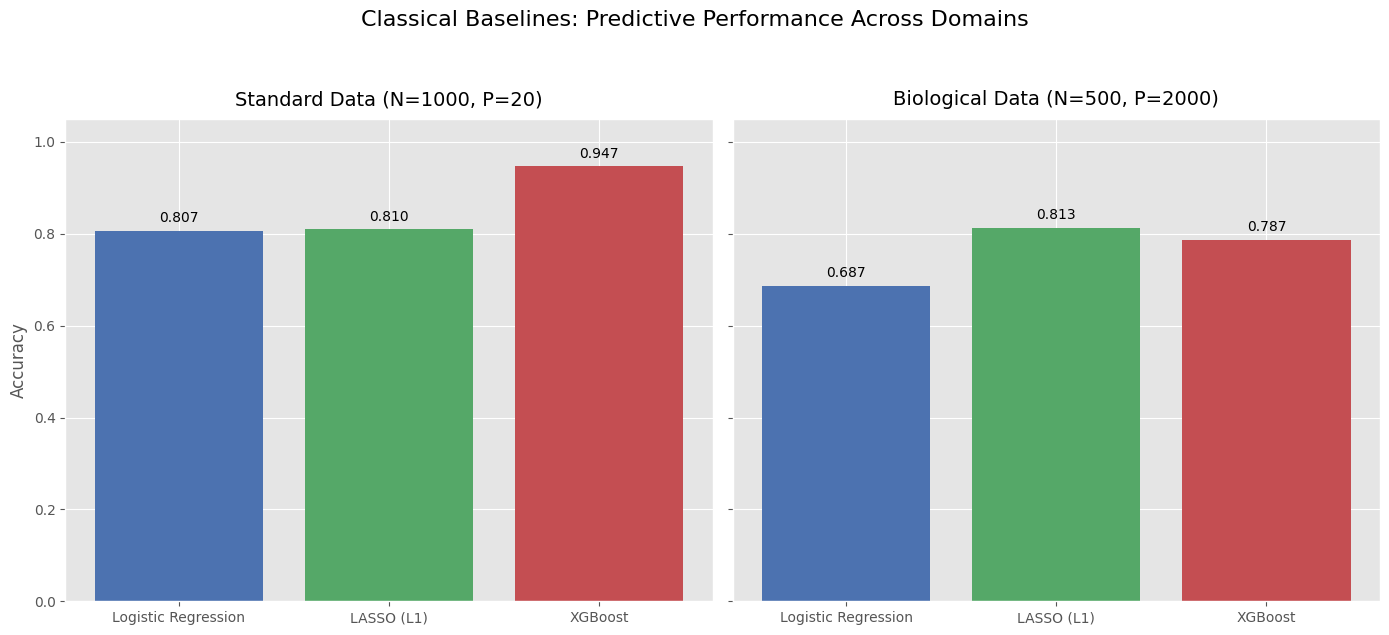

In [4]:
# Gather all results
results = {
    'Logistic Regression': [
        train_and_eval(lr, X_train_std, y_train_std, X_test_std, y_test_std),
        train_and_eval(lr, X_train_bio, y_train_bio, X_test_bio, y_test_bio)
    ],
    'LASSO (L1)':[
        train_and_eval(lasso, X_train_std, y_train_std, X_test_std, y_test_std), 
        train_and_eval(lasso, X_train_bio, y_train_bio, X_test_bio, y_test_bio)          
    ],
    'XGBoost': [xgb_std_acc, xgb_bio_acc]
}

# Setup the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), sharey=True)
models = list(results.keys())

# Standard Data Plot
ax1.bar(models,[res[0] for res in results.values()],color=['#4C72B0', '#55A868', '#C44E52'])
ax1.set_title('Standard Data (N=1000, P=20)', fontsize=14, pad=10)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1.05)

# Biological Data Plot
ax2.bar(models, [res[1] for res in results.values()], color=['#4C72B0', '#55A868', '#C44E52'])
ax2.set_title('Biological Data (N=500, P=2000)', fontsize=14, pad=10)

# Add value labels
for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')
        

plt.suptitle('Classical Baselines: Predictive Performance Across Domains', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


### The Feature Selection Trade-off: Accuracy vs. Efficiency

While raw accuracy is important, in biological and clinical settings, the *cost* of data collection (e.g., sequencing thousands of genes or running clinical tests) is critical. We must evaluate **Feature Efficiency**—how many features a model requires to achieve its predictive power.

The scatter plot below illustrates this trade-off:
* **Logistic Regression & XGBoost:** Consume all available features (20 or 2000), making them highly inefficient and prone to noise in the biological domain.
* **LASSO (L1):** Achieves top-tier accuracy while drastically reducing the feature space (discarding over 95% of the nuisance features). This aggressive feature selection is exactly what makes L1 regularization indispensable for $P \gg N$ problems.

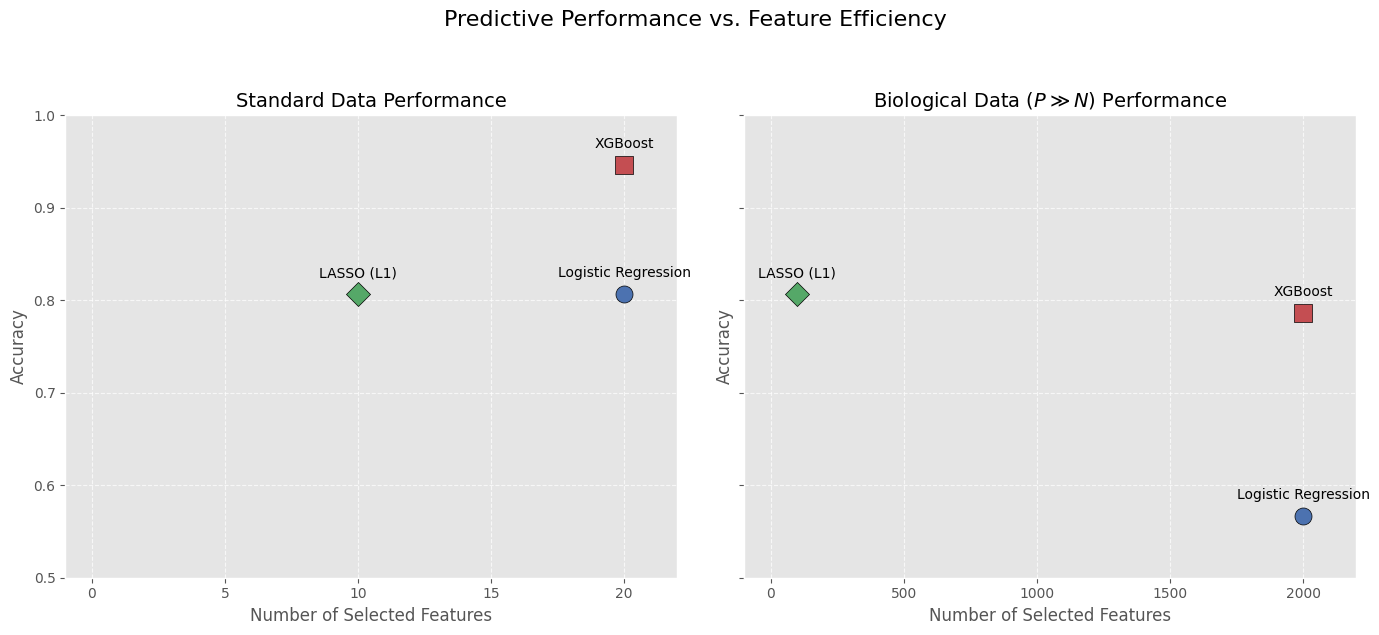

In [5]:

# Gather results for plotting: (Number of Features Used, Test Accuracy)
# Linear Regression and XGBoost use all features. LASSO uses a selected subset.

std_points = {
    'Logistic Regression': (20, lr_std_acc),
    'LASSO (L1)': (retained_std, lasso_std_acc),
    'XGBoost': (20, xgb_std_acc) # Assuming xgb_std_acc is defined from your XGBoost cell
}

bio_points = {
    'Logistic Regression': (2000, lr_bio_acc),
    'LASSO (L1)': (retained_bio, lasso_bio_acc),
    'XGBoost': (2000, xgb_bio_acc) # Assuming xgb_bio_acc is defined from your XGBoost cell
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
colors = {'Logistic Regression': '#4C72B0', 'LASSO (L1)': '#55A868', 'XGBoost': '#C44E52'}
markers = {'Logistic Regression': 'o', 'LASSO (L1)': 'D', 'XGBoost': 's'}

def plot_scatter(ax, data_points, title, max_features):
    for model_name, (n_features, acc) in data_points.items():
        ax.scatter(n_features, acc, s=150, c=colors[model_name], marker=markers[model_name], 
                   label=model_name, edgecolors='black', zorder=3)
        ax.annotate(model_name, (n_features, acc), xytext=(0, 12), 
                    textcoords='offset points', ha='center', fontsize=10)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Number of Selected Features', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xlim(-0.05 * max_features, max_features * 1.1)
    ax.set_ylim(0.5, 1.0)
    ax.grid(True, linestyle='--', alpha=0.7, zorder=0)

# Plot Standard Data
plot_scatter(ax1, std_points, 'Standard Data Performance', 20)

# Plot Biological Data
plot_scatter(ax2, bio_points, 'Biological Data ($P \gg N$) Performance', 2000)

plt.suptitle('Predictive Performance vs. Feature Efficiency', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()